In [2]:
from matplotlib import pyplot as PLOT
import seaborn as SB

# resizing the figure
PLOT.rcParams["figure.figsize"] = [8,2]
# set style to darkgrid
SB.set_style("darkgrid")

# load the dataset
Titanic  = SB.load_dataset("titanic")

#  check the head of the data set
Titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# filtering out the numerical dataset
titanic = Titanic[["survived", "pclass", "age", "fare"]]
titanic.head()

,survived,pclass,age,fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [4]:
#finding the missing value in the dataset
titanic.isnull()

,survived,pclass,age,fare
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
886,False,False,False,False
887,False,False,False,False
888,False,False,True,False
889,False,False,False,False


In [5]:
titanic.isnull().mean()

survived    0.000000
pclass      0.000000
age         0.198653
fare        0.000000
dtype: float64

In [6]:
# the above results shows that 19.86% of age's data is missing

In [7]:
# finding the mean and median of the age dataset
meanAge = titanic.age.mean()
print(int(meanAge))
medianAge = titanic.age.median()
print(medianAge)

29
28.0


In [8]:
#so we are going to add mean age and median age to the data frame using numpy

import numpy as np

titanic["meanAge"] = titanic.age.fillna(meanAge)

# creating the second column
titanic["medianAge"] = titanic.age.fillna(medianAge)

# notice mean age was 29.699... we have to round it to the nearest whole number
titanic["meanAge"] = np.round(titanic['meanAge'],1)

# now lets check for the data of the first 20 lines
titanic.head(20)

C:\Users\appia\AppData\Local\Temp\ipykernel_3532\659635142.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic["meanAge"] = titanic.age.fillna(meanAge)
C:\Users\appia\AppData\Local\Temp\ipykernel_3532\659635142.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic["medianAge"] = titanic.age.fillna(medianAge)
C:\Users\appia\AppData\Local\Temp\ipykernel_3532\659635142.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

,survived,pclass,age,fare,meanAge,medianAge
0,0,3,22.0,7.2500,22.0,22.0
1,1,1,38.0,71.2833,38.0,38.0
2,1,3,26.0,7.9250,26.0,26.0
3,1,1,35.0,53.1000,35.0,35.0
4,0,3,35.0,8.0500,35.0,35.0
5,0,3,NaN,8.4583,29.7,28.0
6,0,1,54.0,51.8625,54.0,54.0
7,0,3,2.0,21.0750,2.0,2.0
8,1,3,27.0,11.1333,27.0,27.0
9,1,2,14.0,30.0708,14.0,14.0


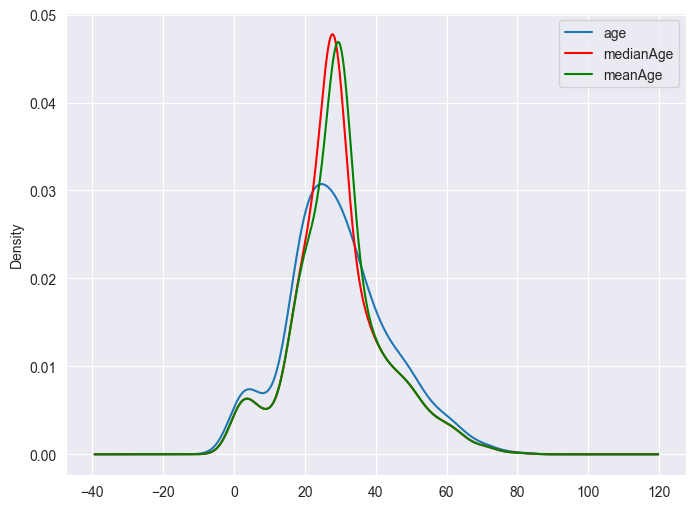

In [9]:
PLOT.rcParams["figure.figsize"] = [8,6]

subPlot=PLOT.figure().add_subplot(111)
titanic['age'] .plot(kind='kde', ax=subPlot)
titanic['medianAge'].plot(kind='kde',ax=subPlot,
color='red')
titanic['meanAge'] .plot(kind='kde', ax=subPlot,
color='green')
lines, labels = subPlot.get_legend_handles_labels()
subPlot.legend(lines, labels, loc='best')